In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


# Xử lý dữ liệu

## Kiểm tra dữ liệu

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, boxcox_normmax
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split

In [3]:
train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')
test_ids = test["Id"]
train = train.drop("Id", axis=1)
test = test.drop("Id", axis=1)
print(train.shape, test.shape)

(1460, 80) (1459, 79)


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [5]:
X=train.drop(['SalePrice'], axis=1)
y=train['SalePrice']

X_train,X_val,y_train,y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [7]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# 1. TẠO BIẾN numeric_features_df
# Tự động lọc ra tất cả các cột mang giá trị số từ tập X_train
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include='object').columns

# 2. KHỞI TẠO MÔ HÌNH IMPUTER
advanced_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42), 
    max_iter=10, 
    random_state=42
)

# 3. THỰC HIỆN ĐIỀN KHUYẾT
# Bước này có thể mất từ vài giây đến 1 phút tùy tốc độ máy vì nó đang chạy mô hình AI để đoán
print("Đang tiến hành điền khuyết bằng Machine Learning...")
X_train[numeric_cols] = advanced_imputer.fit_transform(
    X_train[numeric_cols]
)

X_val[numeric_cols] = advanced_imputer.transform(X_val[numeric_cols])
test[numeric_cols] = advanced_imputer.transform(test[numeric_cols])

Đang tiến hành điền khuyết bằng Machine Learning...


In [8]:
missing = pd.concat([X_train.isnull().sum(),X_train.dtypes],axis=1,keys=["Train","DataType"])
missing = missing[missing["Train"]> 0].sort_values(by="Train",ascending=False)
missing

,Train,DataType
PoolQC,1162,object
MiscFeature,1122,object
Alley,1094,object
Fence,935,object
MasVnrType,683,object
FireplaceQu,547,object
GarageFinish,64,object
GarageQual,64,object
GarageType,64,object
GarageCond,64,object


In [9]:
def handle_missing(df):
    none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 'GarageType', 
                 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 
                 'BsmtFinType1', 'BsmtFinType2']
    for col in none_cols:
        df[col] = df[col].fillna('None')
    
    zero_cols = ['MasVnrArea', 'GarageYrBlt', 'GarageArea', 'GarageCars','BsmtFinSF1', 'BsmtFinSF2', 
                 'BsmtUnfSF', 'TotalBsmtSF','BsmtFullBath', 'BsmtHalfBath']
    for col in zero_cols:
        df[col] = df[col].fillna(0)
    
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda train: train.fillna(train.median()))
    
    remaining_cat = ['Electrical', 'MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'SaleType', 
                     'KitchenQual', 'Functional']
    for col in remaining_cat:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mode()[0])
    
    return df
X_train = handle_missing(X_train)
X_val = handle_missing(X_val)
test = handle_missing(test)

In [10]:
def feature_extraction(df):
    df = df.copy()
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalPorchSF'] = (df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch'])
    
    df['TotalBath'] = (df['FullBath'] + 0.5*df['HalfBath'] + 
                      df['BsmtFullBath'] + 0.5*df['BsmtHalfBath'])
    
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
    df['IsNew'] = (df['YearBuilt'] == df['YrSold']).astype(int)
    
    df['HasPool'] = (df['PoolArea'] > 0).astype(int)
    df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
    df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
    df['HasBsmt'] = (df['TotalBsmtSF'] > 0).astype(int)
    
    df['SF_per_Room'] = df['TotalSF'] / (df['TotRmsAbvGrd'] + 1)
    df['LotArea_per_SF'] = df['LotArea'] / (df['TotalSF'] + 1)
    
    return df
    
X_train = feature_extraction(X_train)
X_val = feature_extraction(X_val)
test = feature_extraction(test)

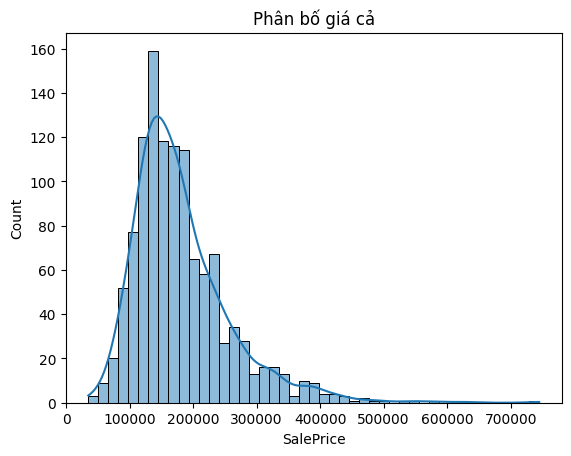

Skewness: 1.7408891554667465


In [11]:
sns.histplot(y_train, kde=True)
plt.title('Phân bố giá cả')
plt.show()
print("Skewness:", skew(y_train)) 

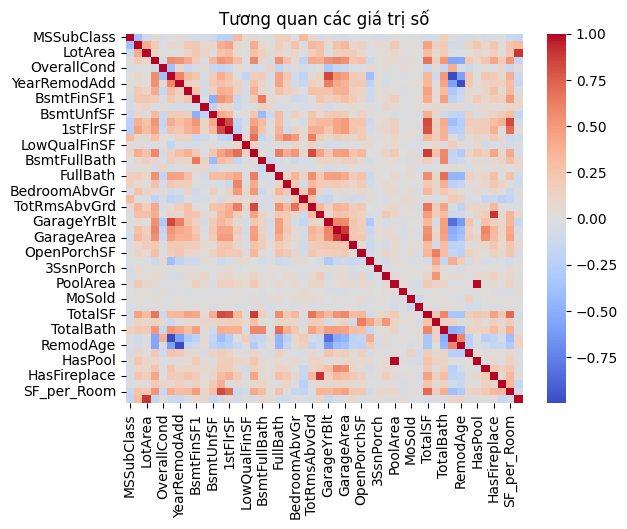

In [12]:
num_cols=X_train.select_dtypes(include=np.number).columns
corr = X_train[num_cols].corr()
sns.heatmap(corr, cmap='coolwarm')
plt.title("Tương quan các giá trị số")
plt.show()

In [13]:
y_train = np.log1p(y_train)
y_val = np.log1p(y_val) 

def handle_skew(df):
    numeric_feats = df.select_dtypes(include=np.number).columns
    
    skewed_feats = df[numeric_feats].apply(lambda x: skew(x.dropna()))
    
    skewed_feats = skewed_feats[(abs(skewed_feats) > 0.75)].index
    
    for feat in skewed_feats:
        if df[feat].nunique() > 1:
            df[feat] = np.log1p(df[feat])
    
    return df
X_train = handle_skew(X_train)
X_val = handle_skew(X_val)
test = handle_skew(test)

In [14]:
def handle_rare_categories(df, threshold=0.05):
    for col in df.select_dtypes(include='object').columns:
        freq = df[col].value_counts(normalize=True)
        rare = freq[freq < threshold].index
        if len(rare) > 0:
            df[col] = df[col].replace(rare, 'Rare')
    return df

X_train = handle_rare_categories(X_train)
X_val = handle_rare_categories(X_val)
test = handle_rare_categories(test)

In [15]:
cat_cols = X_train.select_dtypes(include='object').columns

#Encoder => One Hot
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_encoded = pd.DataFrame(encoder.fit_transform(X_train[cat_cols]),columns=encoder.get_feature_names_out())
X_train = pd.concat([X_train.drop(cat_cols, axis=1).reset_index(drop=True), X_train_encoded], axis=1)

X_val_encoded = pd.DataFrame(encoder.transform(X_val[cat_cols]),columns=encoder.get_feature_names_out())
X_val = pd.concat([X_val.drop(cat_cols, axis=1).reset_index(drop=True), X_val_encoded], axis=1)

test = pd.concat([test.drop(cat_cols, axis=1).reset_index(drop=True),pd.DataFrame(encoder.transform(test[cat_cols]),columns=encoder.get_feature_names_out())], axis=1)

print("Object columns:")
print(X_train.select_dtypes(include='object').columns.tolist())

print("\nData types:")
print(X_train.dtypes.value_counts())
#Scaler
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)
test = pd.DataFrame(scaler.transform(test), columns=test.columns)

#Feature Selection bằng Lasso
lasso = Lasso(alpha=0.0005, random_state=42)
lasso.fit(X_train, y_train)
selected_features = X_train.columns[np.abs(lasso.coef_) !=0]
print(f"Số features sau Lasso: {len(selected_features)}")

X_train = X_train[selected_features]
X_val = X_val[selected_features]
test = test[selected_features]

Object columns:
[]

Data types:
float64    192
int64        1
Name: count, dtype: int64
Số features sau Lasso: 126


In [16]:
X_train = X_train.to_numpy()
X_val = X_val.to_numpy()

y_train = y_train.to_numpy()
y_val = y_val.to_numpy()

# Train

In [17]:
def compute_cost(X,Y,w,b,lambda_):
    m=X.shape[0]
    cost= (X.dot(w)+b-Y)*(X.dot(w)+b-Y)
    reg_cost = (lambda_ / (2 * m)) * np.sum(w ** 2)
    total_cost = np.sum(cost)/(2*m) + reg_cost
    return total_cost

In [18]:
def compute_gradient(X, Y, w, b, lambda_):
    m=X.shape[0]
    tmp = (X.dot(w)+b-Y)
    dj_db = np.sum(X.dot(w)+b-Y)
    dj_dw=X.T.dot(tmp)/m + ((lambda_ / m) * w)
    dj_db/=m
    return dj_dw,dj_db

In [19]:
import copy
def gradient_descent(X_train, Y_train, X_val, Y_val, w_in, b_in, cost_function, gradient_function, alpha, num_iters,patience, lambda_): 
    
    w = copy.deepcopy(w_in)
    b = copy.deepcopy(b_in)

    J_history = []
    J_val_history = []
    w_best = w
    b_best = b
    cost_best = 100000000
    no_improve_count = 0
    
    for i in range(num_iters):
        dj_w,dj_b = gradient_function (X_train,Y_train,w,b,lambda_)
        w = w- alpha*dj_w
        b = b- alpha*dj_b

        cost =  cost_function(X_train, Y_train, w, b,lambda_)
        cost_val = cost_function(X_val, Y_val, w, b,lambda_)
        J_history.append(cost)
        J_val_history.append(cost_val)
        if cost_val < cost_best:
            cost_best=cost_val
            w_best = w
            b_best = b
            no_improve_count = 0
        else:
            no_improve_count +=1
        if no_improve_count >= patience:
            break
    return w_best,b_best,J_history,J_val_history

In [20]:
n_train = X_train.shape[0]
n_feature = X_train.shape[1]
initial_w = np.zeros(n_feature)
initial_b = 0

iterations = 50000
alpha = 0.01
patience = 5
lambda_= 0
w,b,train_loss_history,val_loss_history = gradient_descent(X_train,y_train,X_val,y_val, initial_w, initial_b,compute_cost, compute_gradient, alpha, iterations, patience,lambda_)

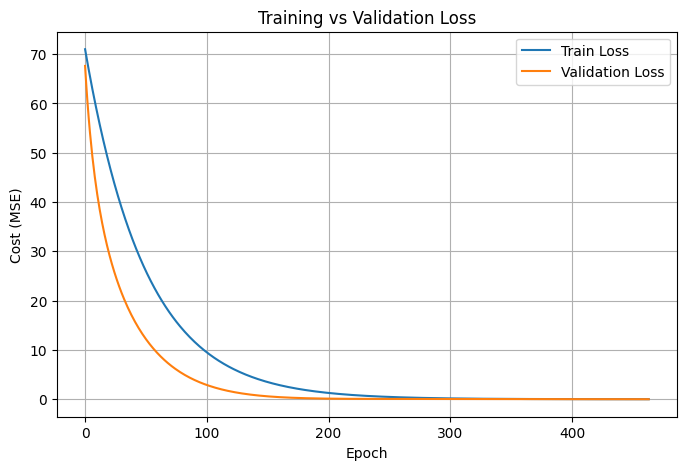

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Cost (MSE)')
plt.title('Training vs Validation Loss')

plt.legend()
plt.grid(True)

plt.show()

In [22]:
y_pred = np.expm1(test.dot(w) + b)
submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": y_pred
})
submission.to_csv("submission.csv", index=False)